In [46]:
!source ml_env/bin/activate

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
column_names = ['engine_id', 'cycle', 'altitude', 'mach_number', 'throttle_angle', 'fan_inlet_temp',
              'LPC_outlet_temp', 'HPC_outlet_temp', 'LPT_outlet_temp', 'fan_inlet_press', 'bypass_press',
              'HPC_outlet_press', 'fan_speed', 'core_speed', 'engine_pressure_ratio', 'HPC_static_outlet_press',
              'fuel_flow_ratio', 'corrected_fan_speed', 'corrected_core_speed', 'bypass_ratio', 'burner_fuel_air_ratio',
              'bleed_enthalpy', 'demanded_fan_speed', 'demanded_corrected_fan_speed', 'HPT_coolant_bleed', 'LPT_coolant_bleed']

print(len(column_names))

26


In [ ]:
# load dataset fcn

def load_all_dataset_to_single_df(DATASET_PATTERNS, column_names, is_train_or_test=True):
    df = pd.DataFrame()
    for dataset in DATASET_PATTERNS:
        temp_df = pd.read_csv(f'data/CMAPSSData/{dataset}.txt', sep='\s+', header=None, index_col=False)
        temp_df['dataset'] = dataset  # add a column to identify the dataset
        df = pd.concat([df, temp_df], ignore_index=True)

    df.columns = list(column_names) + ['dataset']
    
    if is_train_or_test:
        df['engine_id'] = df['engine_id'].astype(str) + '_' + df['dataset'].str[-5:]
        df.drop(columns=['dataset'], inplace=True)
        
    return df

In [5]:
# load dataset for EDA

DATASET_PATTERNS = ['train_FD001']

# load all datasets into a signle dataframe
df = load_all_dataset_to_single_df(DATASET_PATTERNS, column_names)
df.head(10)

,engine_id,cycle,altitude,mach_number,throttle_angle,fan_inlet_temp,LPC_outlet_temp,HPC_outlet_temp,LPT_outlet_temp,fan_inlet_press,...,fuel_flow_ratio,corrected_fan_speed,corrected_core_speed,bypass_ratio,burner_fuel_air_ratio,bleed_enthalpy,demanded_fan_speed,demanded_corrected_fan_speed,HPT_coolant_bleed,LPT_coolant_bleed
0,1_FD001,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1_FD001,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1_FD001,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1_FD001,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1_FD001,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1_FD001,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1_FD001,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1_FD001,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1_FD001,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1_FD001,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


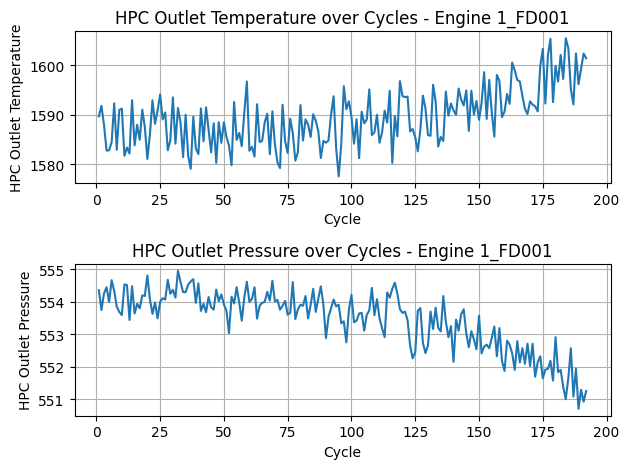

In [6]:
# subplot HPC outlet temperature and pressure over cycles for engine 1

engine_id = '1_FD001'

engine_data = df[df['engine_id'] == engine_id]

ax1 = plt.subplot(2, 1, 1)
ax1.plot(engine_data['cycle'], engine_data['HPC_outlet_temp'])
ax1.set_title(f'HPC Outlet Temperature over Cycles - Engine {engine_id}')
ax1.set_xlabel('Cycle')
ax1.set_ylabel('HPC Outlet Temperature')
ax1.grid()

ax2 = plt.subplot(2, 1, 2)
ax2.plot(engine_data['cycle'], engine_data['HPC_outlet_press'])
ax2.set_title(f'HPC Outlet Pressure over Cycles - Engine {engine_id}')
ax2.set_xlabel('Cycle')
ax2.set_ylabel('HPC Outlet Pressure')
ax2.grid()

plt.tight_layout()

In [7]:
# compute RUL and life ratio for each engine in the training set

def compute_training_rul(df, max_rul=150):
    
    rul_data = df.groupby('engine_id')['cycle'].max().reset_index()
    rul_data.columns = ['engine_id', 'max_cycle']

    df = df.merge(rul_data, on='engine_id', how='left')
    df['RUL'] = df['max_cycle'] - df['cycle']

    df['RUL'] = df['RUL'].clip(upper=max_rul)

    df.drop('max_cycle', axis=1, inplace=True)

    return df

In [8]:
# compute RUL and life ratio for each engine in the training set

MAX_RUL = 150

df = compute_training_rul(df, max_rul=MAX_RUL)

df.head(10)

,engine_id,cycle,altitude,mach_number,throttle_angle,fan_inlet_temp,LPC_outlet_temp,HPC_outlet_temp,LPT_outlet_temp,fan_inlet_press,...,corrected_fan_speed,corrected_core_speed,bypass_ratio,burner_fuel_air_ratio,bleed_enthalpy,demanded_fan_speed,demanded_corrected_fan_speed,HPT_coolant_bleed,LPT_coolant_bleed,RUL
0,1_FD001,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,150
1,1_FD001,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,150
2,1_FD001,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,150
3,1_FD001,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,150
4,1_FD001,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,150
5,1_FD001,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669,150
6,1_FD001,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774,150
7,1_FD001,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106,150
8,1_FD001,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066,150
9,1_FD001,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694,150


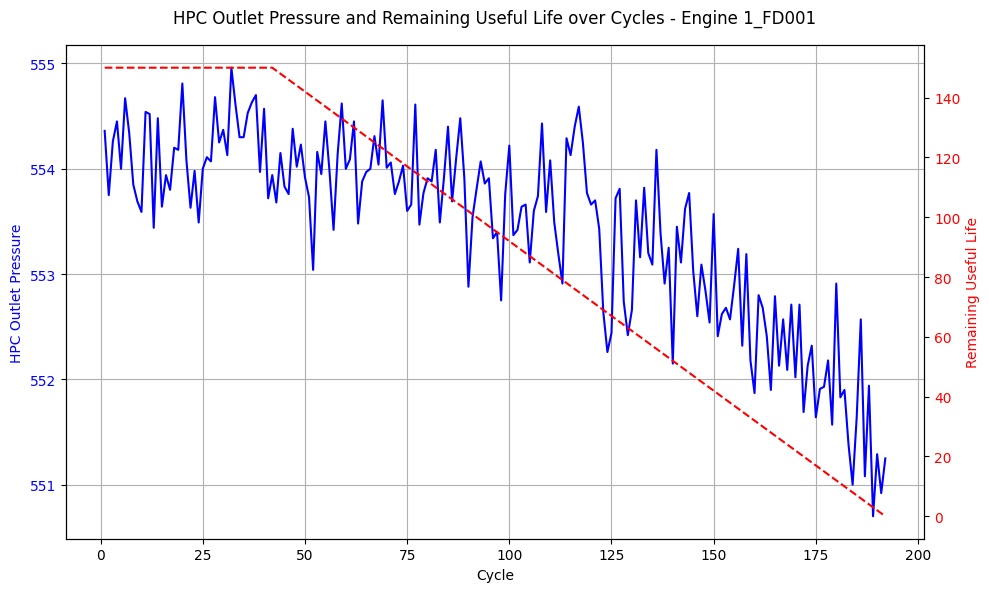

In [54]:
# plot the HPC pressure and the RUL for engine 1 in the same plot with two y-axes

engine_id = '1_FD001'

engine_data = df[df['engine_id'] == engine_id]

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(engine_data['cycle'], engine_data['HPC_outlet_press'], color='b', label='HPC Outlet Pressure')
ax1.set_xlabel('Cycle')
ax1.set_ylabel('HPC Outlet Pressure', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid()

ax2 = ax1.twinx()
ax2.plot(engine_data['cycle'], engine_data['RUL'], color='r', label='Remaining Useful Life', linestyle='--')
ax2.set_ylabel('Remaining Useful Life', color='r')
ax2.tick_params(axis='y', labelcolor='r')
fig.suptitle(f'HPC Outlet Pressure and Remaining Useful Life over Cycles - Engine {engine_id}')

fig.tight_layout()

In [9]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
engine_id,20631,100,69_FD001,362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cycle,20631.0,NaN,NaN,NaN,108.807862,68.88099,1.0,52.0,104.0,156.0,362.0
altitude,20631.0,NaN,NaN,NaN,-0.000009,0.002187,-0.0087,-0.0015,0.0,0.0015,0.0087
mach_number,20631.0,NaN,NaN,NaN,0.000002,0.000293,-0.0006,-0.0002,0.0,0.0003,0.0006
throttle_angle,20631.0,NaN,NaN,NaN,100.0,0.0,100.0,100.0,100.0,100.0,100.0
fan_inlet_temp,20631.0,NaN,NaN,NaN,518.67,0.0,518.67,518.67,518.67,518.67,518.67
LPC_outlet_temp,20631.0,NaN,NaN,NaN,642.680934,0.500053,641.21,642.325,642.64,643.0,644.53
HPC_outlet_temp,20631.0,NaN,NaN,NaN,1590.523119,6.13115,1571.04,1586.26,1590.1,1594.38,1616.91
LPT_outlet_temp,20631.0,NaN,NaN,NaN,1408.933782,9.000605,1382.25,1402.36,1408.04,1414.555,1441.49
fan_inlet_press,20631.0,NaN,NaN,NaN,14.62,0.0,14.62,14.62,14.62,14.62,14.62


In [10]:
# drop non informative sensors (with constant values)
DROP_SENSORS = []

for feature in df.columns:
    try:
        if df[feature].min()==df[feature].max():
            DROP_SENSORS.append(feature)
    except:
        pass

print(DROP_SENSORS)
df.drop(DROP_SENSORS,axis=1,inplace=True)

df.head(10)

['throttle_angle', 'fan_inlet_temp', 'fan_inlet_press', 'engine_pressure_ratio', 'burner_fuel_air_ratio', 'demanded_fan_speed', 'demanded_corrected_fan_speed']


,engine_id,cycle,altitude,mach_number,LPC_outlet_temp,HPC_outlet_temp,LPT_outlet_temp,bypass_press,HPC_outlet_press,fan_speed,core_speed,HPC_static_outlet_press,fuel_flow_ratio,corrected_fan_speed,corrected_core_speed,bypass_ratio,bleed_enthalpy,HPT_coolant_bleed,LPT_coolant_bleed,RUL
0,1_FD001,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,150
1,1_FD001,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,150
2,1_FD001,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,150
3,1_FD001,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,150
4,1_FD001,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,150
5,1_FD001,6,-0.0043,-0.0001,642.10,1584.47,1398.37,21.61,554.67,2388.02,9049.68,47.16,521.68,2388.03,8132.85,8.4108,391,38.98,23.3669,150
6,1_FD001,7,0.0010,0.0001,642.48,1592.32,1397.77,21.61,554.34,2388.02,9059.13,47.36,522.32,2388.03,8132.32,8.3974,392,39.10,23.3774,150
7,1_FD001,8,-0.0034,0.0003,642.56,1582.96,1400.97,21.61,553.85,2388.00,9040.80,47.24,522.47,2388.03,8131.07,8.4076,391,38.97,23.3106,150
8,1_FD001,9,0.0008,0.0001,642.12,1590.98,1394.80,21.61,553.69,2388.05,9046.46,47.29,521.79,2388.05,8125.69,8.3728,392,39.05,23.4066,150
9,1_FD001,10,-0.0033,0.0001,641.71,1591.24,1400.46,21.61,553.59,2388.05,9051.70,47.03,521.79,2388.06,8129.38,8.4286,393,38.95,23.4694,150


In [11]:
def feature_engineering_pipeline(df, windows=[5, 10, 15]):

    df_eng = df.copy()

    SENSORS = [col for col in df_eng.columns if col not in ['engine_id', 'RUL']]

    # get the following rolling statistics for each sensor in fixed windows of cycles per engine:
    # - rolling mean
    # - treading difference between current value and rolling mean
    for w in windows:
        df_eng[[f'{sensor}_RollMean_{w}_Window' for sensor in SENSORS]] = (
            df_eng.groupby('engine_id')[SENSORS]
            .rolling(w, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

        df_eng[[f'{sensor}_inst_val_diff_wrt_RollMean_{w}_Window' for sensor in SENSORS]] = (
            df_eng[[sensor for sensor in SENSORS]].values - df_eng[[f'{sensor}_RollMean_{w}_Window' for sensor in SENSORS]].values
        )

    return df_eng

In [12]:
# feature engineering

WINDOWS = [5, 10, 15]

df_eng = feature_engineering_pipeline(df, windows=WINDOWS)

df_eng.head(10)

/var/folders/6q/cww8_z5x7j16f4g86cdmpm0m0000gn/T/ipykernel_33454/850771194.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[[f'{sensor}_inst_val_diff_wrt_RollMean_{w}_Window' for sensor in SENSORS]] = (
/var/folders/6q/cww8_z5x7j16f4g86cdmpm0m0000gn/T/ipykernel_33454/850771194.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[[f'{sensor}_inst_val_diff_wrt_RollMean_{w}_Window' for sensor in SENSORS]] = (
/var/folders/6q/cww8_z5x7j16f4g86cdmpm0m0000gn/T/ipykernel_33454/850771194.py:18: PerformanceWarning: Data

,engine_id,cycle,altitude,mach_number,LPC_outlet_temp,HPC_outlet_temp,LPT_outlet_temp,bypass_press,HPC_outlet_press,fan_speed,...,fan_speed_inst_val_diff_wrt_RollMean_15_Window,core_speed_inst_val_diff_wrt_RollMean_15_Window,HPC_static_outlet_press_inst_val_diff_wrt_RollMean_15_Window,fuel_flow_ratio_inst_val_diff_wrt_RollMean_15_Window,corrected_fan_speed_inst_val_diff_wrt_RollMean_15_Window,corrected_core_speed_inst_val_diff_wrt_RollMean_15_Window,bypass_ratio_inst_val_diff_wrt_RollMean_15_Window,bleed_enthalpy_inst_val_diff_wrt_RollMean_15_Window,HPT_coolant_bleed_inst_val_diff_wrt_RollMean_15_Window,LPT_coolant_bleed_inst_val_diff_wrt_RollMean_15_Window
0,1_FD001,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1_FD001,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,...,-0.010000,-1.060000,0.010000,0.310000,0.025000,-3.565000,0.006150,0.000000,-0.030000,0.002300
2,1_FD001,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,...,0.020000,5.206667,-0.140000,0.300000,-0.010000,-1.216667,-0.005233,-1.333333,-0.053333,-0.051400
3,1_FD001,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,...,0.037500,1.310000,-0.210000,0.555000,0.030000,-0.462500,-0.041125,0.500000,-0.092500,-0.016275
4,1_FD001,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,...,-0.010000,5.584000,-0.048000,-0.092000,-0.008000,-0.394000,0.016060,1.200000,-0.058000,0.011380
5,1_FD001,6,-0.0043,-0.0001,642.10,1584.47,1398.37,21.61,554.67,2388.02,...,-0.041667,0.095000,-0.140000,-0.501667,-0.015000,-1.120000,-0.002117,-0.666667,0.018333,-0.021767
6,1_FD001,7,0.0010,0.0001,642.48,1592.32,1397.77,21.61,554.34,2388.02,...,-0.035714,8.181429,0.051429,0.118571,-0.012857,-1.414286,-0.013300,0.285714,0.118571,-0.009657
7,1_FD001,8,-0.0034,0.0003,642.56,1582.96,1400.97,21.61,553.85,2388.00,...,-0.048750,-8.880000,-0.060000,0.235000,-0.011250,-2.331250,-0.002712,-0.625000,-0.010000,-0.066900
8,1_FD001,9,0.0008,0.0001,642.12,1590.98,1394.80,21.61,553.69,2388.05,...,0.001111,-2.862222,-0.008889,-0.395556,0.007778,-6.854444,-0.033344,0.333333,0.062222,0.025867
9,1_FD001,10,-0.0033,0.0001,641.71,1591.24,1400.46,21.61,553.59,2388.05,...,0.001000,2.140000,-0.242000,-0.356000,0.016000,-2.848000,0.020210,1.200000,-0.034000,0.079800


In [59]:
# check how many different engines we have in the dataset
print(df_eng['engine_id'].nunique())

100


In [13]:
# train test split
from sklearn.model_selection import GroupShuffleSplit

TARGET = 'RUL' # we will predict the life ratio instead of RUL to have a more normalized target across different engines
FEATURES = [col for col in df_eng.columns if col not in ['engine_id', 'RUL']]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(df_eng[FEATURES], df_eng[TARGET], groups=df_eng['engine_id']))

df_TRAIN = df_eng.iloc[train_idx]
df_TEST = df_eng.iloc[test_idx]

X, y = df_TRAIN[FEATURES], df_TRAIN[TARGET]
X_test, y_test = df_TEST[FEATURES], df_TEST[TARGET]

In [61]:
# # save the train and test sets to csv files for later use
# df.iloc[train_idx].to_csv('data/train_data.csv', index=False)
# df.iloc[test_idx].to_csv('data/test_data.csv', index=False)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import GridSearchCV
from sklearn.compose import TransformedTargetRegressor

    
gkf = GroupKFold(n_splits=5) # group-aware CV to avoid data leakage between engines (entire engine_id in a single fold)

## Random Forest Regressor Pipeline and Hyperparameter Grid
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(
        random_state=42,
        n_jobs=-1
        )
    )
])

rf_model = TransformedTargetRegressor(
    regressor=rf_pipeline,
    transformer=StandardScaler()
)

rf_grid = { # note: we need to prefix the hyperparameters with 'regressor__' to access the RandomForestRegressor inside the TransformedTargetRegressor
    'regressor__rf__n_estimators': [300, 500, 1000],
    'regressor__rf__max_depth': [5, 10, 20, 50, 100],
    'regressor__rf__min_samples_leaf': [5, 10, 20, 50, 100],
    'regressor__rf__max_features': ['sqrt', 'log2', None]
}

# rf_grid = { # note: we need to prefix the hyperparameters with 'regressor__' to access the RandomForestRegressor inside the TransformedTargetRegressor
#     'regressor__rf__n_estimators': [1000],
#     'regressor__rf__max_depth': [50],
#     'regressor__rf__min_samples_leaf': [20],
#     'regressor__rf__max_features': ['sqrt']
# }

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_grid,
    cv=gkf,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=100
)

rf_grid.fit(X, y, groups=df_TRAIN['engine_id'])

Fitting 5 folds for each of 225 candidates, totalling 1125 fits
[CV 2/5; 2/225] START regressor__rf__max_depth=5, regressor__rf__max_features=sqrt, regressor__rf__min_samples_leaf=5, regressor__rf__n_estimators=500
[CV 3/5; 2/225] START regressor__rf__max_depth=5, regressor__rf__max_features=sqrt, regressor__rf__min_samples_leaf=5, regressor__rf__n_estimators=500
[CV 3/5; 1/225] START regressor__rf__max_depth=5, regressor__rf__max_features=sqrt, regressor__rf__min_samples_leaf=5, regressor__rf__n_estimators=300[CV 4/5; 1/225] START regressor__rf__max_depth=5, regressor__rf__max_features=sqrt, regressor__rf__min_samples_leaf=5, regressor__rf__n_estimators=300

[CV 1/5; 2/225] START regressor__rf__max_depth=5, regressor__rf__max_features=sqrt, regressor__rf__min_samples_leaf=5, regressor__rf__n_estimators=500
[CV 2/5; 1/225] START regressor__rf__max_depth=5, regressor__rf__max_features=sqrt, regressor__rf__min_samples_leaf=5, regressor__rf__n_estimators=300
[CV 5/5; 1/225] START regresso

GridSearchCV(cv=GroupKFold(n_splits=5),
             estimator=TransformedTargetRegressor(regressor=Pipeline(steps=[('scaler',
                                                                             StandardScaler()),
                                                                            ('rf',
                                                                             RandomForestRegressor(n_jobs=-1,
                                                                                                   random_state=42))]),
                                                  transformer=StandardScaler()),
             n_jobs=-1,
             param_grid={'regressor__rf__max_depth': [5, 10, 20, 50, 100],
                         'regressor__rf__max_features': ['sqrt', 'log2', None],
                         'regressor__rf__min_samples_leaf': [5, 10, 20, 50,
                                                             100],
                         'regressor__rf__n_estimators': [300, 500, 1000]},
             scoring='neg_mean_absolute_error', verbose=100)

In [ ]:
# # save the best model
# import joblib
# joblib.dump(rf_grid.best_estimator_, 'models/20260211_rf_tuned_model.joblib')

['models/20260211_rf_tuned_model.joblib']

In [64]:
# performance test

from sklearn.metrics import mean_absolute_error

y_test_pred = rf_grid.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_test_pred)

mask_RUL_below_20 = y < 20 # train mask
mask_RUL_below_50 = y < 50 # train mask
mask_RUL_above_50 = y >= 50 # train mask

print(f'Random Forest CV-MAE (TRAINING): {abs(rf_grid.best_score_):.4f}')
print(f'Random Forest CV-MAE (TRAINING, RUL >= 50): {mean_absolute_error(y[mask_RUL_above_50], rf_grid.predict(X)[mask_RUL_above_50]):.4f}')
print(f'Random Forest CV-MAE (TRAINING, RUL < 50): {mean_absolute_error(y[mask_RUL_below_50], rf_grid.predict(X)[mask_RUL_below_50]):.4f}')
print(f'Random Forest CV-MAE (TRAINING, RUL < 20): {mean_absolute_error(y[mask_RUL_below_20], rf_grid.predict(X)[mask_RUL_below_20]):.4f}')

print("################################################################")

mask_RUL_below_20 = y_test < 20 # test mask
mask_RUL_below_50 = y_test < 50 # test mask
mask_RUL_above_50 = y_test >= 50 # test mask

print(f'Random Forest MAE (TEST): {mean_absolute_error(y_test, y_test_pred):.4f}')
print(f'Random Forest MAE (TEST, RUL >= 50): {mean_absolute_error(y_test[mask_RUL_above_50], y_test_pred[mask_RUL_above_50]):.4f}')
print(f'Random Forest MAE (TEST, RUL < 50): {mean_absolute_error(y_test[mask_RUL_below_50], y_test_pred[mask_RUL_below_50]):.4f}')
print(f'Random Forest MAE (TEST, RUL < 20): {mean_absolute_error(y_test[mask_RUL_below_20], y_test_pred[mask_RUL_below_20]):.4f}')


Random Forest CV-MAE (TRAINING): 15.6894
Random Forest CV-MAE (TRAINING, RUL >= 50): 6.5616
Random Forest CV-MAE (TRAINING, RUL < 50): 4.4902
Random Forest CV-MAE (TRAINING, RUL < 20): 1.9255
################################################################
Random Forest MAE (TEST): 12.9432
Random Forest MAE (TEST, RUL >= 50): 14.8169
Random Forest MAE (TEST, RUL < 50): 7.5208
Random Forest MAE (TEST, RUL < 20): 3.1586


In [ ]:
# # load model

# import joblib
# rf_grid = joblib.load('models/20260211_rf_tuned_model.joblib')

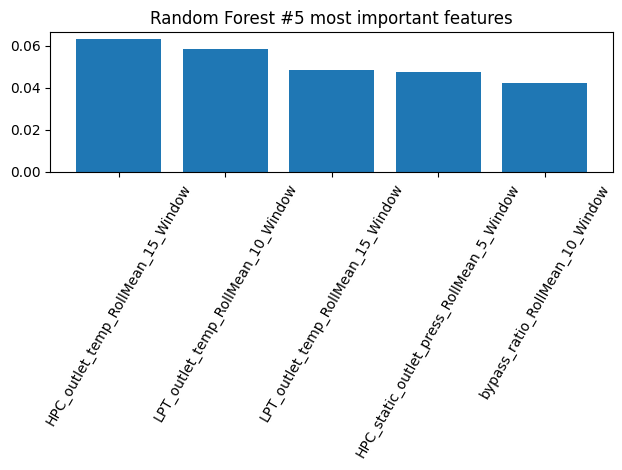

In [41]:

best_rf = (
    rf_grid
        .regressor_
        .named_steps["rf"]
)

importances = best_rf.feature_importances_

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": importances
}).sort_values("importance", ascending=False)

n_features = 5
plt.figure()
plt.bar(importance_df["feature"].iloc[0:n_features], importance_df["importance"].iloc[0:n_features])
plt.xticks(rotation=60)
plt.title(f'Random Forest #{n_features} most important features')
plt.tight_layout()
plt.show()

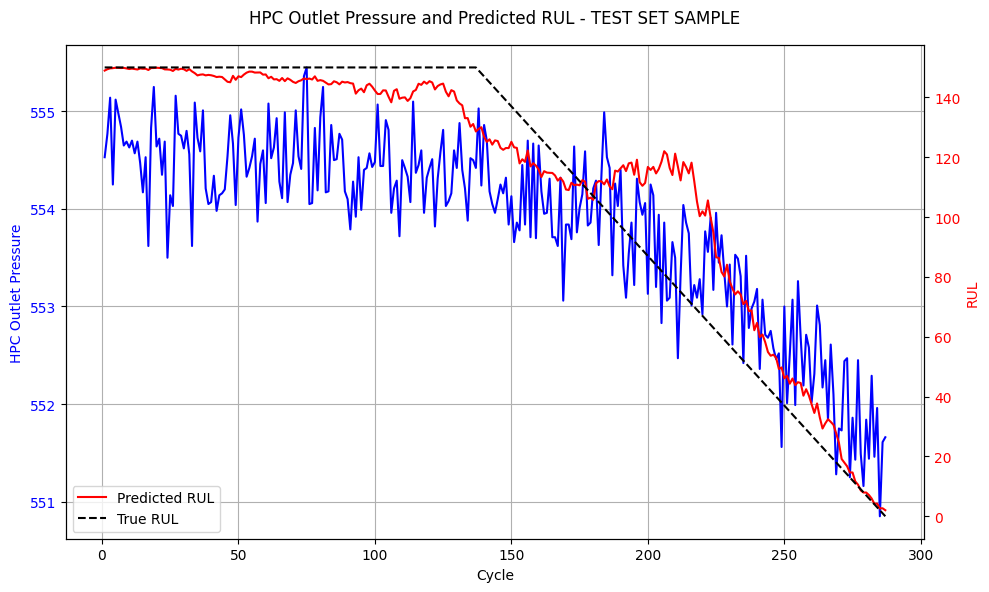

In [31]:
# plot the HPC pressure and the ESTIMATED RUL in the same plot with two y-axes (TEST SAMPLE)

engine_id = df_TEST['engine_id'].unique()[0] # take the first engine in the test set

engine_data = df_TEST[df_TEST['engine_id'] == engine_id]
RUL_pred = rf_grid.predict(df_TEST[df_TEST['engine_id'] == engine_id][FEATURES])

cycles = engine_data['cycle'].values
RUL_pred = RUL_pred.flatten()  # in case it's shape (n,1)

def color_from_RUL_pred(lr):
    if lr < 20:
        return 'red'
    elif lr < 50:
        return 'orange'
    else:
        return 'green'

fig, ax1 = plt.subplots(figsize=(10, 6))

# # background shading
# for i in range(len(cycles) - 1):
#     ax1.axvspan(
#         cycles[i],
#         cycles[i + 1],
#         color=color_from_RUL_pred(RUL_pred[i]),
#         alpha=0.15
#     )

# main signal
ax1.plot(
    cycles,
    engine_data['HPC_outlet_press'],
    color='b',
    label='HPC Outlet Pressure [kPa]'
)

ax1.set_xlabel('Cycle')
ax1.set_ylabel('HPC Outlet Pressure', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid()

# second axis
ax2 = ax1.twinx()
ax2.plot(cycles, RUL_pred, color='r', label='Predicted RUL')
ax2.plot(cycles, engine_data['RUL'].values, color='k', label='True RUL', linestyle='--')
ax2.set_ylabel('RUL', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.legend(loc="lower left")

# # add an horizontal line at RUL=20 and RUL=50 to visualize the thresholds
# ax2.axhline(y=20, color='red', linestyle='--', label='RUL=20 Threshold')
# ax2.axhline(y=50, color='orange', linestyle='--', label='RUL=50 Threshold')

fig.suptitle(
    f'HPC Outlet Pressure and Predicted RUL - TEST SET SAMPLE'
)

fig.tight_layout()
plt.show()
